# Reddit vs IMDb vs Rotten Tomatoes — Movie Rating Comparison

Comparing Reddit sentiment scores against IMDb ratings and Rotten Tomatoes scores across genres and regions.

**Data sources:**
- Reddit comments (44k+ comments, scored via VADER + TextBlob + RoBERTa blend)
- IMDb ratings from OMDB API
- Rotten Tomatoes scores from OMDB API
- Movie metadata from TMDB

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
print("Libraries loaded!")

Libraries loaded!


In [2]:
import snowflake.connector
from dotenv import load_dotenv
import os

load_dotenv()

conn = snowflake.connector.connect(
    user="ATHULYA2303",
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account="gsc07824.us-east-1",
    warehouse="COMPUTE_WH",
    database="MOVIE_ANALYTICS",
    schema="RAW"
)

# load movie master (has IMDB + RT ratings)
movies = pd.read_sql("SELECT * FROM RAW.MOVIES_MASTER", conn)
print(f"Movies master: {len(movies)} movies")
print(f"Columns: {movies.columns.tolist()}")

conn.close()

Movies master: 571 movies
Columns: ['TMDB_ID', 'IMDB_ID', 'TITLE', 'YEAR', 'GENRE', 'REGION', 'IMDB_RATING', 'RT_SCORE', 'POPULARITY']


In [3]:
# load reddit movie scores from the sentiment analysis
reddit = pd.read_csv("data/reddit_movie_scores.csv")
print(f"Reddit scores: {len(reddit)} movies")
reddit.head()

Reddit scores: 209 movies


,movie_name,reddit_score,vader_avg,textblob_avg,roberta_avg,total_comments,explicit_ratings,positive_pct,negative_pct,neutral_pct
0,Lubber Pandhu,7.44,6.843333,6.748667,7.870667,15,0,66.7,6.7,26.7
1,Bigfoot Exorcist,7.14,6.972778,6.273333,7.490000,18,0,77.8,5.6,16.7
2,Sevappi,7.14,7.136667,6.993333,7.193333,3,0,66.7,0.0,33.3
3,Sirf Ek Bandaa Kaafi Hai,7.06,6.887833,6.374500,7.353667,60,0,76.7,6.7,16.7
4,Theera Kaadhal,6.87,7.345000,6.708333,6.537000,30,1,73.3,13.3,13.3


## 2. Merge Reddit Scores with IMDb & RT

Joining on movie title. We need to clean up RT score (remove %) and normalize everything to the same scale.

In [4]:
# clean up column names for the join
movies.columns = [c.lower() for c in movies.columns]

# merge on title
df = reddit.merge(
    movies,
    left_on="movie_name",
    right_on="title",
    how="inner"
)

print(f"Matched {len(df)} movies out of {len(reddit)} Reddit-scored movies")
print(f"Lost {len(reddit) - len(df)} movies (no match in master table)")

Matched 209 movies out of 209 Reddit-scored movies
Lost 0 movies (no match in master table)


In [5]:
# clean RT score — remove % and convert to number
df["rt_score_num"] = df["rt_score"].str.replace("%", "").astype(float)

# normalize everything to 1-10 scale for fair comparison
# IMDb is already 1-10
# RT is 0-100, convert to 1-10
# Reddit is already 1-10

df["rt_score_10"] = (df["rt_score_num"] / 10).round(2)  # 88% -> 8.8
df["imdb_rating"] = df["imdb_rating"].astype(float)

# keep only movies where we have all 3 scores
df = df.dropna(subset=["reddit_score", "imdb_rating", "rt_score_10"])
print(f"Movies with all 3 ratings: {len(df)}")
print()

# quick look at the data
df[["movie_name", "reddit_score", "imdb_rating", "rt_score_10", "genre", "region", "total_comments"]].head(10)

Movies with all 3 ratings: 108



,movie_name,reddit_score,imdb_rating,rt_score_10,genre,region,total_comments
5,Train Dreams,6.87,7.5,9.5,Drama,Hollywood,623
7,Ice Road: Vengeance,6.83,4.8,1.5,"Action, Adventure, Thriller",Hollywood,77
8,Sukhee,6.73,5.9,1.7,"Comedy, Drama",Bollywood,25
9,Birth/Rebirth,6.67,6.2,9.5,"Drama, Horror, Thriller",Hollywood,145
12,The Hunger Games: The Ballad of Songbirds & Sn...,6.60,6.6,6.4,"Action, Adventure, Drama",Hollywood,430
15,Superboys of Malegaon,6.57,7.7,8.7,"Comedy, Drama",Bollywood,66
17,Maaveeran,6.55,7.4,10.0,"Action, Comedy, Drama",Kollywood,165
18,Abigail,6.53,6.5,8.3,"Action, Comedy, Crime",Hollywood,520
20,Vijay 69,6.49,6.1,6.4,"Comedy, Drama, Sport",Bollywood,107
21,The Equalizer 3,6.47,6.8,7.6,"Action, Crime, Thriller",Hollywood,323


## 3. Overall Comparison — Reddit vs IMDb vs RT

In [6]:
# basic stats
print("=== Rating Summary ===")
print(f"Reddit  — Mean: {df['reddit_score'].mean():.2f}, Median: {df['reddit_score'].median():.2f}, Std: {df['reddit_score'].std():.2f}")
print(f"IMDb    — Mean: {df['imdb_rating'].mean():.2f}, Median: {df['imdb_rating'].median():.2f}, Std: {df['imdb_rating'].std():.2f}")
print(f"RT (/10)— Mean: {df['rt_score_10'].mean():.2f}, Median: {df['rt_score_10'].median():.2f}, Std: {df['rt_score_10'].std():.2f}")

=== Rating Summary ===
Reddit  — Mean: 5.88, Median: 5.95, Std: 0.49
IMDb    — Mean: 6.46, Median: 6.60, Std: 1.11
RT (/10)— Mean: 6.07, Median: 6.55, Std: 2.91


In [7]:
# correlation between all 3 platforms
print("=== Correlations ===")
print(f"Reddit vs IMDb:  {df['reddit_score'].corr(df['imdb_rating']):.3f}")
print(f"Reddit vs RT:    {df['reddit_score'].corr(df['rt_score_10']):.3f}")
print(f"IMDb vs RT:      {df['imdb_rating'].corr(df['rt_score_10']):.3f}")
print()

# statistical significance
r_imdb, p_imdb = stats.pearsonr(df["reddit_score"], df["imdb_rating"])
r_rt, p_rt = stats.pearsonr(df["reddit_score"], df["rt_score_10"])
r_imdb_rt, p_imdb_rt = stats.pearsonr(df["imdb_rating"], df["rt_score_10"])

print(f"Reddit vs IMDb:  r={r_imdb:.3f}, p={p_imdb:.4f} {'✅ Significant' if p_imdb < 0.05 else '❌ Not significant'}")
print(f"Reddit vs RT:    r={r_rt:.3f}, p={p_rt:.4f} {'✅ Significant' if p_rt < 0.05 else '❌ Not significant'}")
print(f"IMDb vs RT:      r={r_imdb_rt:.3f}, p={p_imdb_rt:.4f} {'✅ Significant' if p_imdb_rt < 0.05 else '❌ Not significant'}")

=== Correlations ===
Reddit vs IMDb:  0.263
Reddit vs RT:    0.298
IMDb vs RT:      0.685

Reddit vs IMDb:  r=0.263, p=0.0059 ✅ Significant
Reddit vs RT:    r=0.298, p=0.0017 ✅ Significant
IMDb vs RT:      r=0.685, p=0.0000 ✅ Significant


In [24]:
# only keep movies with enough Reddit data to be meaningful
min_comments = 20

df_filtered = df[df["total_comments"] >= min_comments]
print(f"Movies with {min_comments}+ comments: {len(df_filtered)}")
print(f"Dropped: {len(df) - len(df_filtered)} movies with too few comments")
print()

# recalculate correlations
print("Correlations (filtered):")
print(f"  Reddit vs IMDb: {df_filtered['reddit_score'].corr(df_filtered['imdb_rating']):.3f}")
print(f"  Reddit vs RT:   {df_filtered['reddit_score'].corr(df_filtered['rt_score_10']):.3f}")
print(f"  IMDb vs RT:     {df_filtered['imdb_rating'].corr(df_filtered['rt_score_10']):.3f}")

Movies with 20+ comments: 108
Dropped: 0 movies with too few comments

Correlations (filtered):
  Reddit vs IMDb: 0.263
  Reddit vs RT:   0.298
  IMDb vs RT:     0.685


In [25]:
for min_c in [50, 100, 150, 200]:
    filtered = df[df["total_comments"] >= min_c]
    if len(filtered) >= 10:
        r_imdb = filtered["reddit_score"].corr(filtered["imdb_rating"])
        r_rt = filtered["reddit_score"].corr(filtered["rt_score_10"])
        print(f"Min {min_c:3d} comments → {len(filtered):3d} movies | Reddit-IMDb: {r_imdb:.3f} | Reddit-RT: {r_rt:.3f}")

Min  50 comments → 102 movies | Reddit-IMDb: 0.257 | Reddit-RT: 0.310
Min 100 comments →  79 movies | Reddit-IMDb: 0.287 | Reddit-RT: 0.280
Min 150 comments →  68 movies | Reddit-IMDb: 0.300 | Reddit-RT: 0.321
Min 200 comments →  52 movies | Reddit-IMDb: 0.069 | Reddit-RT: 0.030


## 4. Scatter Plots — Visual Correlation

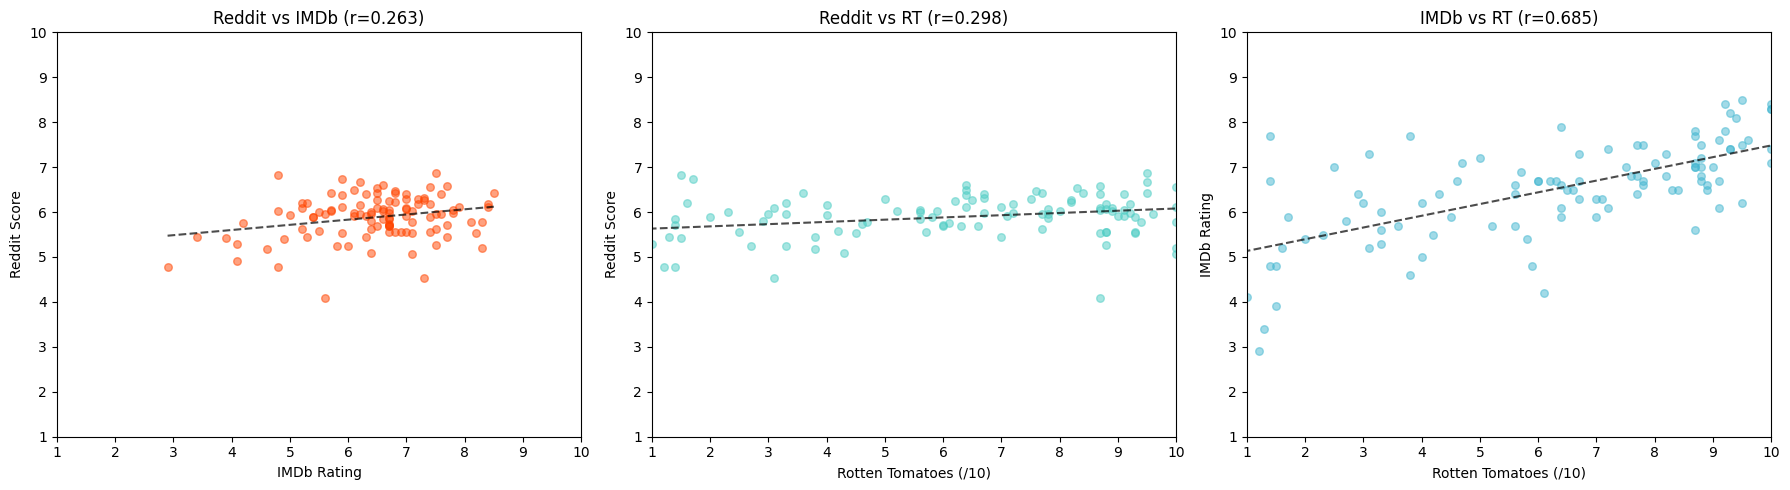

Saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reddit vs IMDb
axes[0].scatter(df["imdb_rating"], df["reddit_score"], alpha=0.5, c="#FF4500", s=30)
z = np.polyfit(df["imdb_rating"], df["reddit_score"], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df["imdb_rating"]), p(sorted(df["imdb_rating"])), "k--", alpha=0.7)
axes[0].set_xlabel("IMDb Rating")
axes[0].set_ylabel("Reddit Score")
axes[0].set_title(f"Reddit vs IMDb (r={r_imdb:.3f})")
axes[0].set_xlim(1, 10)
axes[0].set_ylim(1, 10)

# Reddit vs RT
axes[1].scatter(df["rt_score_10"], df["reddit_score"], alpha=0.5, c="#4ECDC4", s=30)
z2 = np.polyfit(df["rt_score_10"], df["reddit_score"], 1)
p2 = np.poly1d(z2)
axes[1].plot(sorted(df["rt_score_10"]), p2(sorted(df["rt_score_10"])), "k--", alpha=0.7)
axes[1].set_xlabel("Rotten Tomatoes (/10)")
axes[1].set_ylabel("Reddit Score")
axes[1].set_title(f"Reddit vs RT (r={r_rt:.3f})")
axes[1].set_xlim(1, 10)
axes[1].set_ylim(1, 10)

# IMDb vs RT
axes[2].scatter(df["rt_score_10"], df["imdb_rating"], alpha=0.5, c="#45B7D1", s=30)
z3 = np.polyfit(df["rt_score_10"], df["imdb_rating"], 1)
p3 = np.poly1d(z3)
axes[2].plot(sorted(df["rt_score_10"]), p3(sorted(df["rt_score_10"])), "k--", alpha=0.7)
axes[2].set_xlabel("Rotten Tomatoes (/10)")
axes[2].set_ylabel("IMDb Rating")
axes[2].set_title(f"IMDb vs RT (r={r_imdb_rt:.3f})")
axes[2].set_xlim(1, 10)
axes[2].set_ylim(1, 10)

plt.tight_layout()
plt.savefig("data/platform_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 5. Biggest Disagreements

Which movies does Reddit rate very differently from IMDb and RT?

In [9]:
# difference between reddit and imdb
df["reddit_vs_imdb"] = (df["reddit_score"] - df["imdb_rating"]).round(2)
df["reddit_vs_rt"] = (df["reddit_score"] - df["rt_score_10"]).round(2)
df["abs_diff_imdb"] = abs(df["reddit_vs_imdb"])
df["abs_diff_rt"] = abs(df["reddit_vs_rt"])

print("=== Reddit rates HIGHER than IMDb (Reddit loves, IMDb meh) ===")
cols = ["movie_name", "reddit_score", "imdb_rating", "reddit_vs_imdb", "total_comments", "genre"]
print(df.sort_values("reddit_vs_imdb", ascending=False)[cols].head(10).to_string(index=False))

print()
print("=== Reddit rates LOWER than IMDb (Reddit hates, IMDb likes) ===")
print(df.sort_values("reddit_vs_imdb", ascending=True)[cols].head(10).to_string(index=False))

=== Reddit rates HIGHER than IMDb (Reddit loves, IMDb meh) ===
               movie_name  reddit_score  imdb_rating  reddit_vs_imdb  total_comments                       genre
              Housefull 5          5.45          3.4            2.05             173   Comedy, Mystery, Thriller
      Ice Road: Vengeance          6.83          4.8            2.03              77 Action, Adventure, Thriller
               Nadaaniyan          4.78          2.9            1.88              94              Drama, Romance
              The Archies          5.75          4.2            1.55             260      Comedy, Drama, Musical
 Indian 2: Zero Tolerance          5.43          3.9            1.53             168     Action, Drama, Thriller
                  Coyotes          6.02          4.8            1.22             668     Comedy, Drama, Thriller
               Madame Web          5.28          4.1            1.18             571            Action, Thriller
Five Nights at Freddy's 2        

In [10]:
print("=== Reddit rates HIGHER than RT ===")
cols_rt = ["movie_name", "reddit_score", "rt_score_10", "reddit_vs_rt", "total_comments", "genre"]
print(df.sort_values("reddit_vs_rt", ascending=False)[cols_rt].head(10).to_string(index=False))

print()
print("=== Reddit rates LOWER than RT ===")
print(df.sort_values("reddit_vs_rt", ascending=True)[cols_rt].head(10).to_string(index=False))

=== Reddit rates HIGHER than RT ===
                    movie_name  reddit_score  rt_score_10  reddit_vs_rt  total_comments                       genre
                         Siren          5.62          0.0          5.62              88     Action, Crime, Thriller
                     Mumbaikar          5.41          0.0          5.41             159     Action, Drama, Thriller
           Ice Road: Vengeance          6.83          1.5          5.33              77 Action, Adventure, Thriller
                        Sukhee          6.73          1.7          5.03              25               Comedy, Drama
                 Param Sundari          5.62          0.7          4.92             152                     Romance
                  Dream Girl 2          5.44          0.8          4.64             156      Comedy, Drama, Romance
     Five Nights at Freddy's 2          6.21          1.6          4.61             456   Horror, Mystery, Thriller
               August 16, 1947      

## 6. Comparison by Genre

Do certain genres get rated differently across platforms?

In [11]:
# movies can have multiple genres ("Action, Comedy, Drama")
# explode so each genre gets its own row
df["genre_list"] = df["genre"].str.split(", ")
genre_df = df.explode("genre_list")

# average rating per genre per platform
genre_avg = genre_df.groupby("genre_list").agg(
    reddit_avg = ("reddit_score", "mean"),
    imdb_avg = ("imdb_rating", "mean"),
    rt_avg = ("rt_score_10", "mean"),
    movie_count = ("movie_name", "count")
).reset_index()

# only genres with enough movies
genre_avg = genre_avg[genre_avg["movie_count"] >= 5]
genre_avg = genre_avg.sort_values("movie_count", ascending=False)

print(f"Genres with 5+ movies: {len(genre_avg)}")
genre_avg.round(2)

Genres with 5+ movies: 13


,genre_list,reddit_avg,imdb_avg,rt_avg,movie_count
7,Drama,5.89,6.76,6.67,62
0,Action,5.89,6.42,5.42,43
4,Comedy,5.95,6.37,6.05,35
18,Thriller,5.80,5.92,5.20,30
1,Adventure,5.98,6.40,6.08,24
5,Crime,5.90,6.46,5.73,16
11,Horror,5.91,6.14,6.35,16
15,Romance,5.65,6.17,5.35,12
3,Biography,6.00,7.62,7.10,9
10,History,5.65,7.61,6.74,7


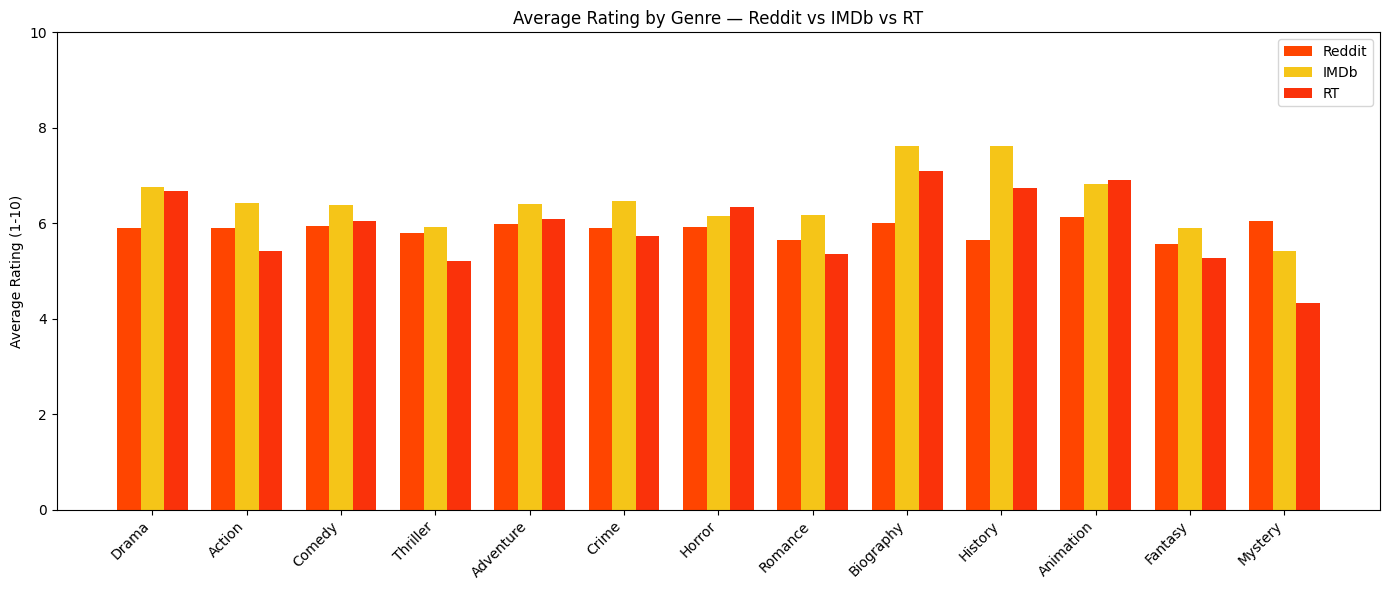

Saved!


In [12]:
# genre comparison chart
fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(genre_avg))
width = 0.25

ax.bar([i - width for i in x], genre_avg["reddit_avg"], width, label="Reddit", color="#FF4500")
ax.bar(x, genre_avg["imdb_avg"], width, label="IMDb", color="#F5C518")
ax.bar([i + width for i in x], genre_avg["rt_avg"], width, label="RT", color="#FA320A")

ax.set_xticks(x)
ax.set_xticklabels(genre_avg["genre_list"], rotation=45, ha="right")
ax.set_ylabel("Average Rating (1-10)")
ax.set_title("Average Rating by Genre — Reddit vs IMDb vs RT")
ax.legend()
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig("data/genre_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [13]:
# which genres have the biggest gap between reddit and imdb/rt?
genre_avg["reddit_vs_imdb_gap"] = (genre_avg["reddit_avg"] - genre_avg["imdb_avg"]).round(2)
genre_avg["reddit_vs_rt_gap"] = (genre_avg["reddit_avg"] - genre_avg["rt_avg"]).round(2)

print("=== Genre Gaps (Reddit minus IMDb) ===")
print("Positive = Reddit rates higher, Negative = Reddit rates lower")
print(genre_avg[["genre_list", "reddit_avg", "imdb_avg", "reddit_vs_imdb_gap", "movie_count"]].sort_values("reddit_vs_imdb_gap", ascending=False).to_string(index=False))

=== Genre Gaps (Reddit minus IMDb) ===
Positive = Reddit rates higher, Negative = Reddit rates lower
genre_list  reddit_avg  imdb_avg  reddit_vs_imdb_gap  movie_count
   Mystery    6.052000  5.420000                0.63            5
  Thriller    5.798000  5.923333               -0.13           30
    Horror    5.913125  6.143750               -0.23           16
   Fantasy    5.560000  5.900000               -0.34            5
    Comedy    5.946857  6.371429               -0.42           35
 Adventure    5.984167  6.404167               -0.42           24
   Romance    5.652500  6.166667               -0.51           12
    Action    5.890000  6.418605               -0.53           43
     Crime    5.898750  6.462500               -0.56           16
 Animation    6.138000  6.820000               -0.68            5
     Drama    5.889839  6.759677               -0.87           62
 Biography    6.000000  7.622222               -1.62            9
   History    5.651429  7.614286         

## 7. Comparison by Region

Hollywood vs Bollywood vs Kollywood vs Tollywood vs Mollywood — how do platforms compare across regional cinema?

In [14]:
region_avg = df.groupby("region").agg(
    reddit_avg = ("reddit_score", "mean"),
    imdb_avg = ("imdb_rating", "mean"),
    rt_avg = ("rt_score_10", "mean"),
    movie_count = ("movie_name", "count"),
    avg_comments = ("total_comments", "mean")
).reset_index()

region_avg = region_avg.sort_values("movie_count", ascending=False)
print("Average Ratings by Region:")
region_avg.round(2)

Average Ratings by Region:


,region,reddit_avg,imdb_avg,rt_avg,movie_count,avg_comments
1,Hollywood,6.03,6.59,7.02,55,389.51
0,Bollywood,5.68,6.23,4.90,41,127.54
2,Kollywood,5.90,6.61,5.69,12,126.25


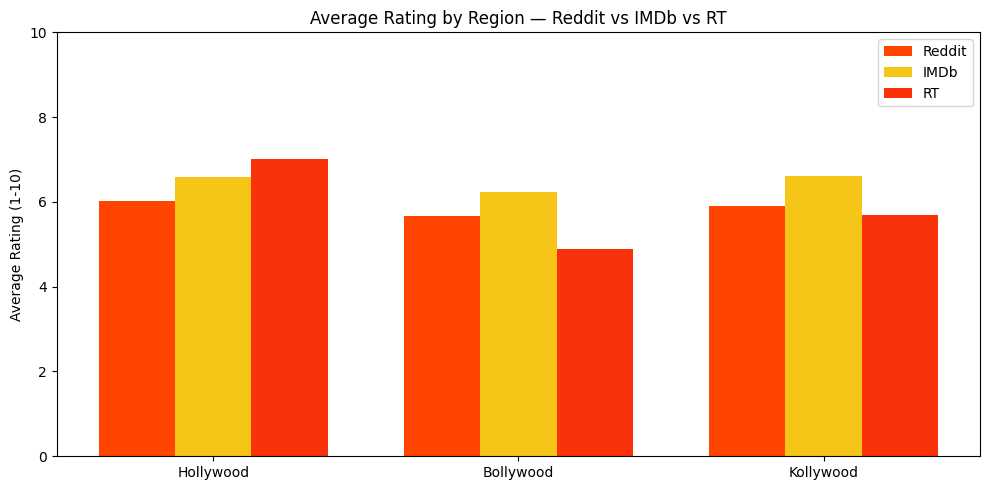

Saved!


In [15]:
# region comparison chart
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(region_avg))
width = 0.25

ax.bar([i - width for i in x], region_avg["reddit_avg"], width, label="Reddit", color="#FF4500")
ax.bar(x, region_avg["imdb_avg"], width, label="IMDb", color="#F5C518")
ax.bar([i + width for i in x], region_avg["rt_avg"], width, label="RT", color="#FA320A")

ax.set_xticks(x)
ax.set_xticklabels(region_avg["region"])
ax.set_ylabel("Average Rating (1-10)")
ax.set_title("Average Rating by Region — Reddit vs IMDb vs RT")
ax.legend()
ax.set_ylim(0, 10)

plt.tight_layout()
plt.savefig("data/region_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 8. Correlation Heatmap

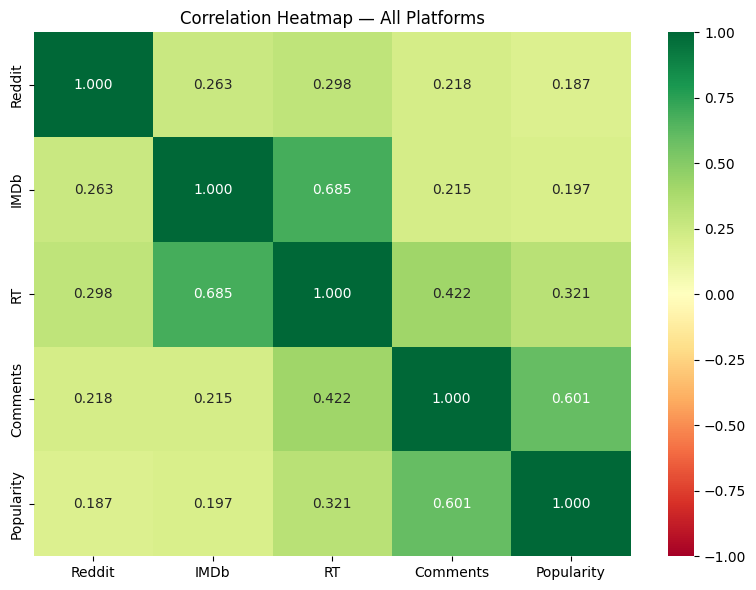

Saved!


In [16]:
# correlation matrix
corr_cols = ["reddit_score", "imdb_rating", "rt_score_10", "total_comments", "popularity"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt=".3f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    xticklabels=["Reddit", "IMDb", "RT", "Comments", "Popularity"],
    yticklabels=["Reddit", "IMDb", "RT", "Comments", "Popularity"],
    ax=ax
)
ax.set_title("Correlation Heatmap — All Platforms")
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 9. Rating Distribution Comparison

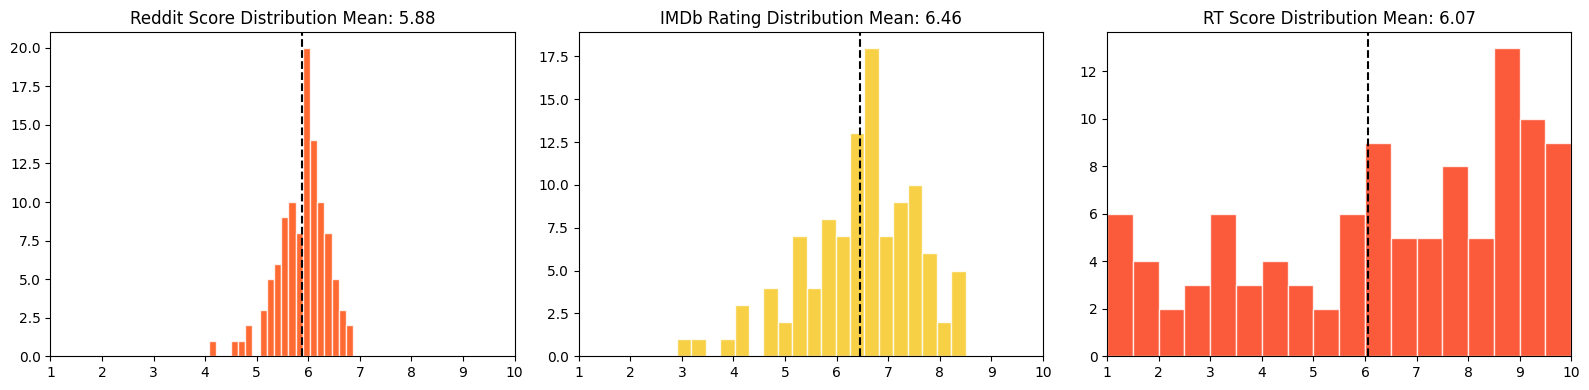

Saved!


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df["reddit_score"], bins=20, color="#FF4500", alpha=0.8, edgecolor="white")
axes[0].set_title(f"Reddit Score Distribution Mean: {df['reddit_score'].mean():.2f}")
axes[0].set_xlim(1, 10)
axes[0].axvline(df["reddit_score"].mean(), color="black", linestyle="--")

axes[1].hist(df["imdb_rating"], bins=20, color="#F5C518", alpha=0.8, edgecolor="white")
axes[1].set_title(f"IMDb Rating Distribution Mean: {df['imdb_rating'].mean():.2f}")
axes[1].set_xlim(1, 10)
axes[1].axvline(df["imdb_rating"].mean(), color="black", linestyle="--")

axes[2].hist(df["rt_score_10"], bins=20, color="#FA320A", alpha=0.8, edgecolor="white")
axes[2].set_title(f"RT Score Distribution Mean: {df['rt_score_10'].mean():.2f}")
axes[2].set_xlim(1, 10)
axes[2].axvline(df["rt_score_10"].mean(), color="black", linestyle="--")

plt.tight_layout()
plt.savefig("data/distribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 10. Reddit Sentiment Over Time

Does Reddit sentiment change over time? Looking at comment-level data with timestamps.

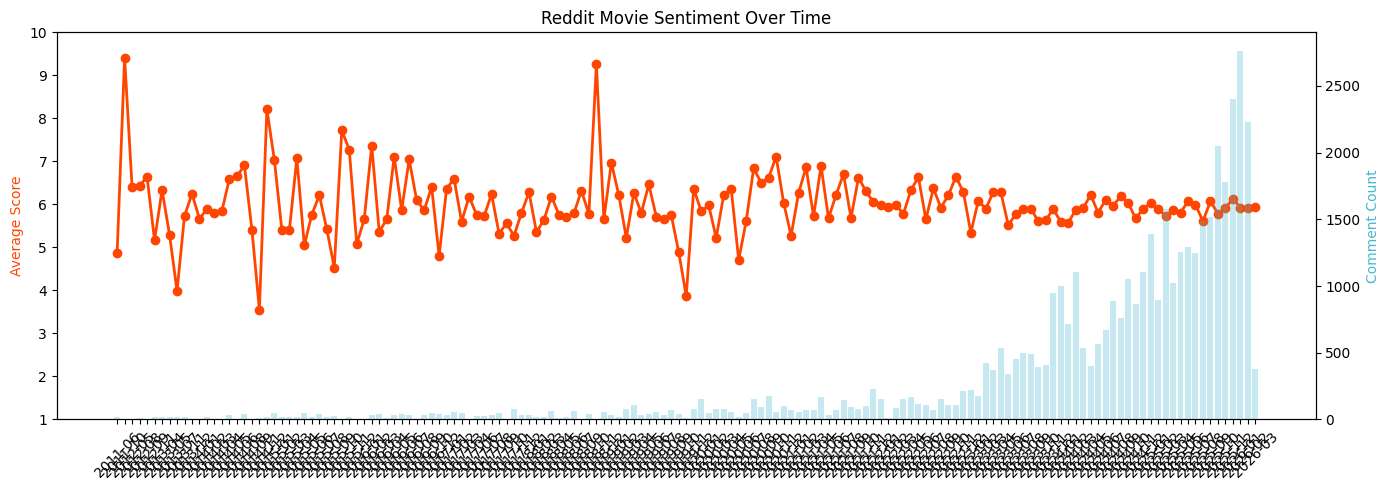

Saved!


In [21]:
# load full comment data with timestamps
comments = pd.read_csv("data/reddit_sentiment_scored.csv")
comments["comment_timestamp"] = pd.to_datetime(comments["comment_timestamp"])
comments["month"] = comments["comment_timestamp"].dt.to_period("M")

# average sentiment by month
monthly = comments.groupby("month").agg(
    avg_score = ("final_score", "mean"),
    comment_count = ("final_score", "count")
).reset_index()

monthly["month_str"] = monthly["month"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(monthly["month_str"], monthly["avg_score"], "o-", color="#FF4500", linewidth=2, label="Avg Reddit Score")
ax1.set_ylabel("Average Score", color="#FF4500")
ax1.set_ylim(1, 10)

ax2 = ax1.twinx()
ax2.bar(monthly["month_str"], monthly["comment_count"], alpha=0.3, color="#45B7D1", label="Comment Volume")
ax2.set_ylabel("Comment Count", color="#45B7D1")

ax1.set_title("Reddit Movie Sentiment Over Time")
ax1.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.savefig("data/sentiment_over_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 11. Summary & Key Findings

In [22]:
print("="*60)
print("KEY FINDINGS")
print("="*60)
print()
print(f"Total movies compared: {len(df)}")
print(f"Total Reddit comments analyzed: {df['total_comments'].sum():,}")
print()
print("--- Overall ---")
print(f"Reddit avg: {df['reddit_score'].mean():.2f} | IMDb avg: {df['imdb_rating'].mean():.2f} | RT avg: {df['rt_score_10'].mean():.2f}")
print()
print("--- Correlations ---")
print(f"Reddit-IMDb: {df['reddit_score'].corr(df['imdb_rating']):.3f}")
print(f"Reddit-RT:   {df['reddit_score'].corr(df['rt_score_10']):.3f}")
print(f"IMDb-RT:     {df['imdb_rating'].corr(df['rt_score_10']):.3f}")
print()
print("--- Interpretation ---")
r_val = df["reddit_score"].corr(df["imdb_rating"])
if r_val > 0.7:
    print("Reddit and IMDb are strongly correlated — similar opinions.")
elif r_val > 0.4:
    print("Reddit and IMDb are moderately correlated — some agreement but notable differences.")
elif r_val > 0.2:
    print("Reddit and IMDb are weakly correlated — Reddit users often disagree with IMDb.")
else:
    print("Reddit and IMDb show very little correlation — essentially independent rating systems.")
print()
print("--- Biggest Reddit vs IMDb disagreement ---")
biggest = df.loc[df["abs_diff_imdb"].idxmax()]
print(f"{biggest['movie_name']}: Reddit={biggest['reddit_score']:.1f}, IMDb={biggest['imdb_rating']:.1f} (diff={biggest['reddit_vs_imdb']:.1f})")

KEY FINDINGS

Total movies compared: 108
Total Reddit comments analyzed: 28,167

--- Overall ---
Reddit avg: 5.88 | IMDb avg: 6.46 | RT avg: 6.07

--- Correlations ---
Reddit-IMDb: 0.263
Reddit-RT:   0.298
IMDb-RT:     0.685

--- Interpretation ---
Reddit and IMDb are weakly correlated — Reddit users often disagree with IMDb.

--- Biggest Reddit vs IMDb disagreement ---
Viduthalai: Part I: Reddit=5.2, IMDb=8.3 (diff=-3.1)


## 12. Save Final Comparison Data

In [23]:
# save the merged comparison data
output_cols = [
    "movie_name", "year", "genre", "region",
    "reddit_score", "vader_avg", "textblob_avg", "roberta_avg",
    "imdb_rating", "rt_score_10", "rt_score",
    "total_comments", "explicit_ratings", "positive_pct", "negative_pct",
    "reddit_vs_imdb", "reddit_vs_rt", "popularity"
]

final = df[output_cols].sort_values("total_comments", ascending=False)
final.to_csv("data/platform_comparison.csv", index=False)
print(f"Saved comparison for {len(final)} movies to data/platform_comparison.csv")
print()
print("All done! You now have:")
print("  - data/reddit_sentiment_scored.csv (44k scored comments)")
print("  - data/reddit_movie_scores.csv (209 movie scores)")
print("  - data/platform_comparison.csv (Reddit vs IMDb vs RT)")
print("  - Charts in data/ folder")

Saved comparison for 108 movies to data/platform_comparison.csv

All done! You now have:
  - data/reddit_sentiment_scored.csv (44k scored comments)
  - data/reddit_movie_scores.csv (209 movie scores)
  - data/platform_comparison.csv (Reddit vs IMDb vs RT)
  - Charts in data/ folder


## 13. Push to Snowflake (uncomment when ready)

In [ ]:
# conn = snowflake.connector.connect(
#     user="ATHULYA2303",
#     password=os.getenv("SNOWFLAKE_PASSWORD"),
#     account="gsc07824.us-east-1",
#     warehouse="COMPUTE_WH",
#     database="MOVIE_ANALYTICS",
#     schema="ANALYTICS"
# )
# 
# from snowflake.connector.pandas_tools import write_pandas
# 
# push = final.copy()
# push.columns = [c.upper() for c in push.columns]
# write_pandas(conn, push, "PLATFORM_COMPARISON",
#              database="MOVIE_ANALYTICS", schema="ANALYTICS",
#              overwrite=True)
# 
# conn.close()
# print("Pushed to Snowflake!")